# 1. Data Preparation and Sampling

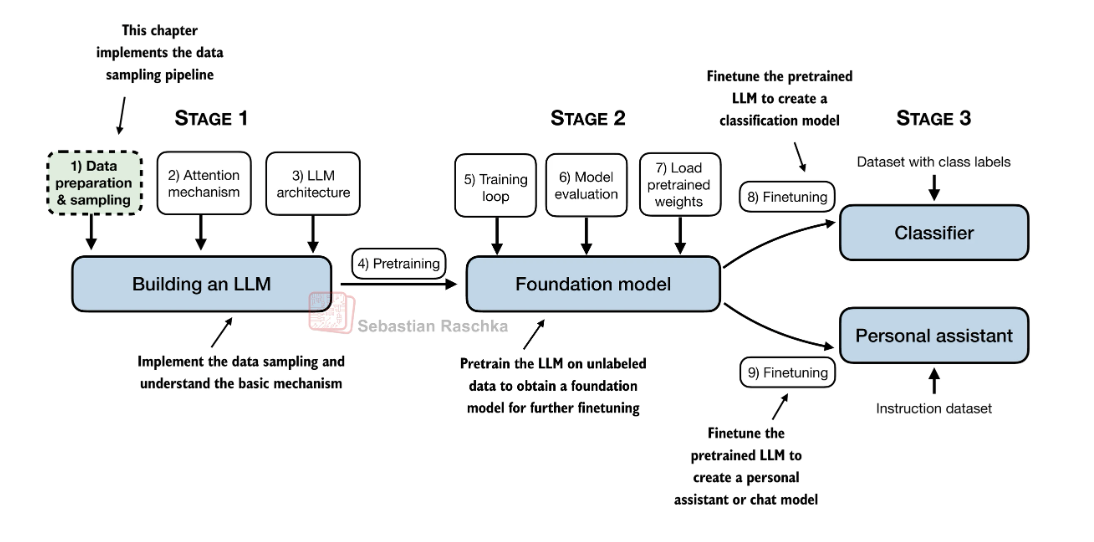

In [1]:
from importlib.metadata import version
# importlib.metadata presents access to metadata from third-party distributions.

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.9.1
tiktoken version: 0.12.0


#### Tokenizing text

Tokenization breaks down the training set into individual tokens. The new tokenized sample text is mapped to token IDs using an existing vocabulary.

#### Read text

In [2]:
import os
import requests
import re

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )

    file_path = "the-verdict.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)


In [3]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total number of characters:", len(raw_text))
print(raw_text[:99])

Total number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


#### Preprocess text to create tokens

In [4]:
# import re

# text = "Hello, world. This, is a test."
# result = re.split(r'(\s)', text) # by space
# result = re.split(r'([,.]|\s)', text) # by punctuation and space
# result = [item for item in result if item.strip()] # remove empty strings
# print(result)

In [5]:
# text = "Hello, world. Is this-- a test?"

# result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
# result = [item.strip() for item in result if item.strip()]
# print(result)

In [6]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [7]:
# total number of tokens created
print(len(preprocessed))

4690


#### Converting tokens into token IDs

In [8]:
# Building a vocab consisting of all unique tokens

all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print(vocab_size)

1130


In [9]:
vocab = {token:integer for integer,token in enumerate(all_words)}

In [10]:
# Checking first 50 entries in the vocab

for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


#### Putting it together into a tokenizer class

In [11]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [12]:
tokenizer = SimpleTokenizerV1(vocab)

text = """"It's the last he painted, you know," 
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)


[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [13]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

In [14]:
tokenizer.decode(tokenizer.encode(text))

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

#### Adding special context tokens
It's useful to add some special tokens for unknown words and to denote the end of a text
Example:
* [BOS] (beginning of sequence) 
* [EOS] (end of sequence)
* [PAD] (padding) if we train LLMs with a batch size greater than 1 (we may include multiple texts with different lengths; with the padding token we pad the shorter texts to the longest length so that all texts have an equal length)
* [UNK] unknown

Note that GPT-2 does not need any of these tokens mentioned above but only uses an <|endoftext|> token to reduce complexity

The <|endoftext|> is analogous to the [EOS] token mentioned above

GPT also uses the <|endoftext|> for padding (since we typically use a mask when training on batched inputs, we would not attend padded tokens anyways, so it does not matter what these tokens are)

GPT-2 does not use an <UNK> token for out-of-vocabulary words; instead, GPT-2 uses a byte-pair encoding (BPE) tokenizer, which breaks down words into subword units which we will discuss in a later section

In [15]:
# tokenizer = SimpleTokenizerV1(vocab)

# text = "Hello, do you like tea. Is this-- a test?"

# tokenizer.encode(text)

The above cell gives error because the word "Hello" is not part of vocab.

In [16]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftoken|>", "<|unk|>"])

vocab = {token:integer for integer,token in enumerate(all_tokens)}

In [17]:
len(vocab.items())

1132

In [18]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftoken|>', 1130)
('<|unk|>', 1131)


In [19]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]
        
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [20]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [21]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 1131, 55, 988, 956, 984, 722, 988, 1131, 7]

In [22]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|unk|> In the sunlit terraces of the <|unk|>.'

### BytePair Encoding (BPE)
GPT-2 uses BPE as its tokenizer

In [23]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.12.0


In [24]:
tokenizer = tiktoken.get_encoding("gpt2")

In [25]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)


[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [26]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


### Data Sampling with a sliding window

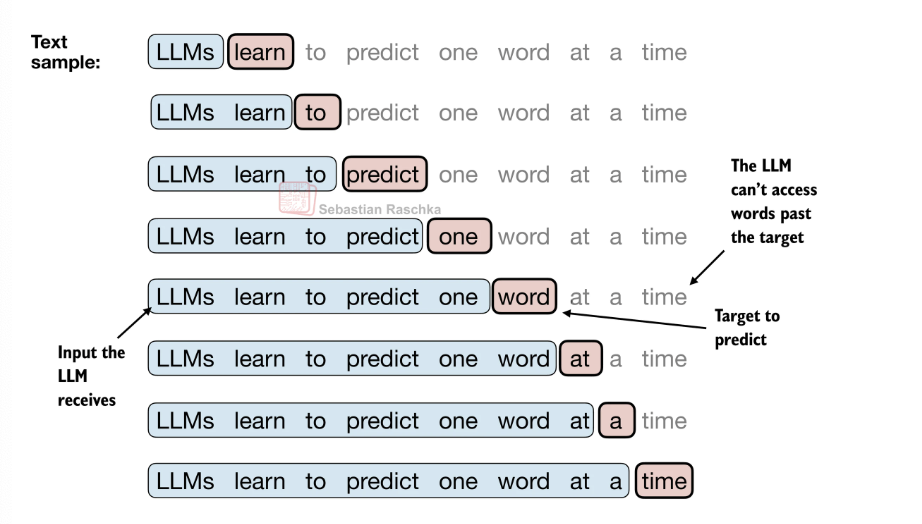

In [27]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [28]:
enc_sample = enc_text[50:]

In [29]:
context_size = 7

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287, 257, 4489, 64]
y:      [4920, 2241, 287, 257, 4489, 64, 319]


In [30]:
# Prediction would look like:

for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257
[290, 4920, 2241, 287, 257] ----> 4489
[290, 4920, 2241, 287, 257, 4489] ----> 64
[290, 4920, 2241, 287, 257, 4489, 64] ----> 319


In [31]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a
 and established himself in a ---->  vill
 and established himself in a vill ----> a
 and established himself in a villa ---->  on


#### Data Loader - iterates over the input dataset and returns the inputs and targets shifted by one.

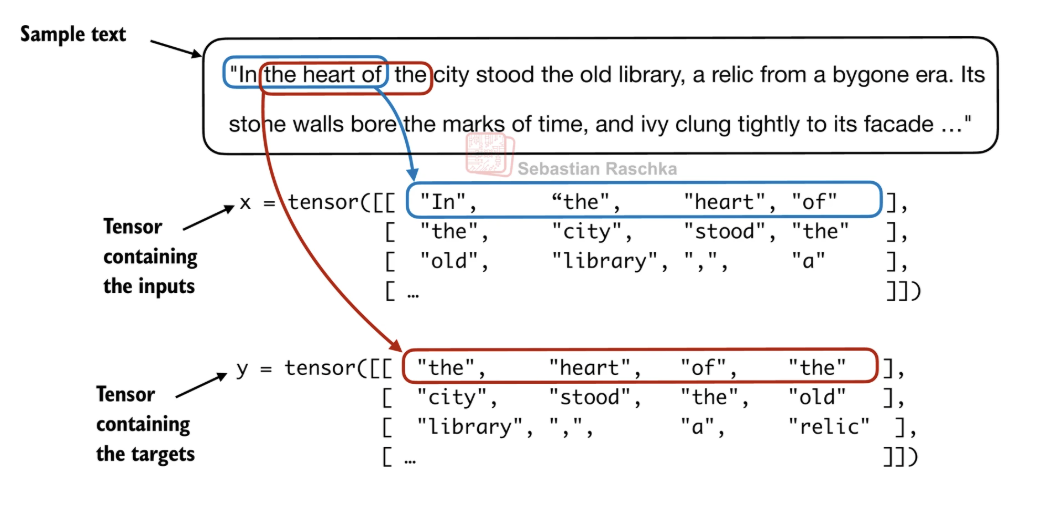

In [32]:
import torch

print("PyTorch version:", torch.__version__)

PyTorch version: 2.9.1


In [33]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        #Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

        # Use sliding window to chunk the book into overlapping sequences of max_length 
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1: i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [34]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    dataloader = DataLoader(
        dataset,
        batch_size = batch_size,
        shuffle = shuffle,
        drop_last = drop_last,
        num_workers = num_workers
    )

    return dataloader

Test dataloader with a batch size of 1 for an LLM with context size of 4

In [35]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [36]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [37]:
# dataloader = create_dataloader_v1(
#     raw_text, batch_size=5, max_length=4, stride=1, shuffle=False
# )

# data_iter = iter(dataloader)
# first_batch = next(data_iter)
# print(first_batch)

In [38]:
# dataloader = create_dataloader_v1(
#     raw_text, batch_size=4, max_length=7, stride=1, shuffle=False
# )

# data_iter = iter(dataloader)
# first_batch = next(data_iter)
# print(first_batch)

In [39]:
# dataloader = create_dataloader_v1(
#     raw_text, batch_size=4, max_length=7, stride=3, shuffle=False
# )

# data_iter = iter(dataloader)
# first_batch = next(data_iter)
# print(first_batch)

In [40]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


* Note: We increase the stride so that we don't have overlaps between the batches, since more overlap could lead to increased overfitting

In [41]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


#### Creating token embeddings

* Lastly, let us embed the tokens in a continuous vector representation using an embedding layer
* Usually, these embedding layers are part of the LLM itself and are updated (trained) during model training

The embedding layer approach is essentially just a more efficient way of implementing one-hot encoding followed by matrix multiplication in a fully-connected layer.

Because the embedding layer is just a more efficient implementation that is equivalent to the one-hot encoding and matrix-multiplication approach it can be seen as a neural network layer that can be optimized via backpropagation

In [42]:
# Example

input_ids = torch.tensor([2,3,5,1]) #token_ids for which embeddings are needed
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [43]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [44]:
# To convert a token with id 3 into a 3-dimensional vector, we do the following:

print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [45]:
print(embedding_layer(torch.tensor([1])))

tensor([[0.9178, 1.5810, 1.3010]], grad_fn=<EmbeddingBackward0>)


In [46]:
print(embedding_layer(torch.tensor([1, 3])))

tensor([[ 0.9178,  1.5810,  1.3010],
        [-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [47]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


### Positional Encoding

* The BytePair encoder has a vocabulary size of 50,257:
* Suppose we want to encode the input tokens into a 256-dimensional vector representation:

In [48]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [49]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [50]:
print("Token IDs: \n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs: 
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [51]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape) # x-axis: batch, y-axis: context length, z-axis: embedding dimension

torch.Size([8, 4, 256])


In [52]:
print(token_embeddings)

tensor([[[ 0.4913,  1.1239,  1.4588,  ..., -0.3995, -1.8735, -0.1445],
         [ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
         [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483]],

        [[ 1.5460,  1.7368, -0.7848,  ..., -0.1004,  0.8584, -0.3421],
         [-1.8622, -0.1914, -0.3812,  ...,  1.1220, -0.3496,  0.6091],
         [ 1.9847, -0.6483, -0.1415,  ..., -0.3841, -0.9355,  1.4478],
         [ 0.9647,  1.2974, -1.6207,  ...,  1.1463,  1.5797,  0.3969]],

        [[-0.7713,  0.6572,  0.1663,  ..., -0.8044,  0.0542,  0.7426],
         [ 0.8046,  0.5047,  1.2922,  ...,  1.4648,  0.4097,  0.3205],
         [ 0.0795, -1.7636,  0.5750,  ...,  2.1823,  1.8231, -0.3635],
         [ 0.4267, -0.0647,  0.5686,  ..., -0.5209,  1.3065,  0.8473]],

        ...,

        [[-1.6156,  0.9610, -2.6437,  ..., -0.9645,  1.0888,  1.6383],
         [-0.3985, -0.9235, -1.3163,  ..., -1.1582, -1.13

GPT-2 uses absolute position embeddings, so we just create another embedding layer:

In [53]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

print(pos_embedding_layer.weight)

Parameter containing:
tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       requires_grad=True)


In [54]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [55]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


In [56]:
print(input_embeddings)

tensor([[[ 2.2288,  0.5619,  0.8286,  ..., -0.6272, -0.2987,  0.8900],
         [ 2.0903, -0.4664, -0.0593,  ...,  0.9115, -1.0493, -1.6473],
         [-0.7158, -0.8304,  1.2494,  ...,  2.3952,  1.8773,  0.8051],
         [ 0.2703,  0.4029,  3.0514,  ...,  0.3595, -1.4548,  0.8310]],

        [[ 3.2835,  1.1749, -1.4150,  ..., -0.3281,  2.4332,  0.6924],
         [-0.2199, -0.9114, -0.1750,  ...,  1.5337, -0.1998,  0.1462],
         [ 1.5197, -1.4240,  0.4391,  ...,  1.0494, -1.4318,  2.3057],
         [ 0.2893,  0.8346, -0.1884,  ...,  1.9602,  0.8709,  0.8796]],

        [[ 0.9662,  0.0952, -0.4640,  ..., -1.0320,  1.6290,  1.7771],
         [ 2.4468, -0.2154,  1.4984,  ...,  1.8766,  0.5595, -0.1423],
         [-0.3856, -2.5393,  1.1556,  ...,  3.6157,  1.3267,  0.4944],
         [-0.2487, -0.5275,  2.0009,  ...,  0.2930,  0.5977,  1.3300]],

        ...,

        [[ 0.1219,  0.3991, -3.2740,  ..., -1.1921,  2.6637,  2.6728],
         [ 1.2438, -1.6436, -1.1101,  ..., -0.7464, -0.98

# 2. Attention Mechanism

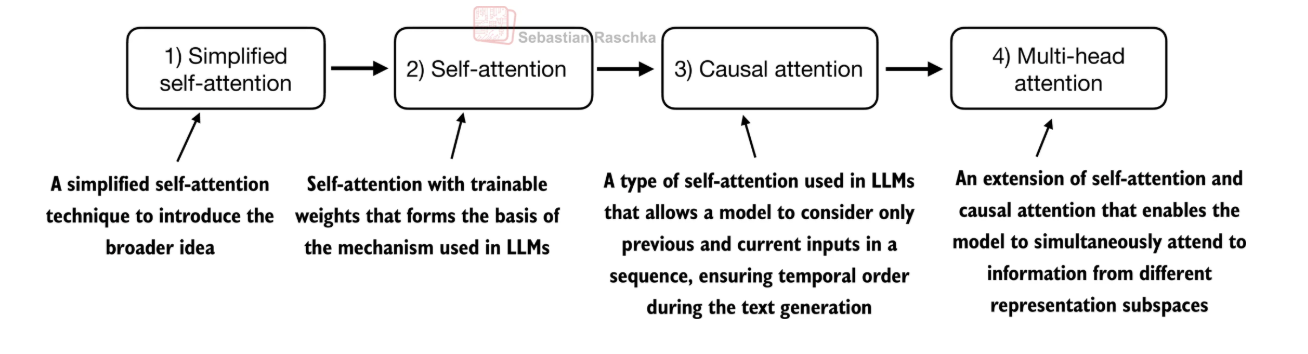

Goal: compute context vectors z(i) for each input sequence element x(i), where z and x have the same dimension.
* A context vector z(i) is a weighted sum over the inputs x(1) to x(t)

#### 2.1 Simple self-attention mechanism without trainable weights (not how it is actually done in transformer architecture)

query as input (dot product) input

Example sentence for below sample of simplified self-attention (not how it is done in actual transformer):
* "Your journey starts with one step"

In [57]:
from importlib.metadata import version

print("torch version:", version("torch"))

torch version: 2.9.1


In [58]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], #Your     (x^1)
     [0.55, 0.87, 0.66], #journey  (x^2)
     [0.57, 0.85, 0.64], #starts   (x^3)
     [0.22, 0.58, 0.33], #with     (x^4)
     [0.77, 0.25, 0.10], #one      (x^5)
     [0.05, 0.80, 0.55]] #step     (x^6)
)

In [59]:
inputs[1]

tensor([0.5500, 0.8700, 0.6600])

Step 1: compute unnormalized attention scores w

For input sequence x(1) to x(t), querying for input 2 i.e q(2) = x(2):    <br>
* w21 = x(1)q(2)^T      <br>
* w22 = x(2)q(2)^T      <br>
* w23 = x(3)q(2)^T      <br>
* ...      <br>
* w2t = x(t)q(2)^T      <br>

In [ ]:
query = inputs[1] #2nd input token, x^2, is the query q^2 #[0.55, 0.87, 0.66]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    print(i, x_i)
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [61]:
res = 0. # inputs[0] is the first input token, x^1 #[0.43, 0.15, 0.89]

for idx, element in enumerate(inputs[0]):
    res += inputs[0][idx] * query[idx]

print(res)
print(torch.dot(inputs[0], query))

tensor(0.9544)
tensor(0.9544)


Step 2: normalize the unnormalize attention scores so that they sum up to 1 (a convention, useful for interpretation, and important for training stability)

In [62]:
attn_weights_2_tmp = attn_scores_2/attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


In practice, using the softmax function for normalization, which is better at handling extreme values and has more desirable gradient properties during training, is common and recommended

In [63]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


The naive implementation above can suffer from numerical instability issues for large or small input values due to overflow and underflow issues

In practice, its recommended to use the PyTorch implementation of softmax instead, which has been highly optimized for performance.

In [64]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


Step 3: Compute the context vector z(2) by multiplying the embedded input tokens, x(i) with the attention weights and sum the resulting vectors

In [65]:
# The context-vector is a "context" that is specific to a certain input
# The context vector, z(i), is a weighted sum over all inputs x(1) to x(t) weighted with respect to x(i)
# i.e. update input vector with incorprated attention weights

query = inputs[1]

context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


Generalizing computing attention weights for ALL input sequence tokens

In [66]:
# Compute unnormalized attention scores w for ALL pairwise input elements

attn_scores = torch.empty(6,6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [67]:
# same can be achieved more efficiently via matrix multiplication:

attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [68]:
# normalize each row so that the values in each row sum to 1

attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [69]:
# verification that values in each row are 1
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)

print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [70]:
# compute all context vectors i.e. update input vector with incorprated attention weights

all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [71]:
# for sanity check, previous 2nd context vector
 
print("Previous 2nd context vector:", context_vec_2) 

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


#### 2.2 Self attention with trainable weights (Scaled dot product attention)

#### (Used in original transformer architecture, GPT models and most other popular LLMs)

Here, unlike earlier --> query = inputs[1] i.e. q(i) = x(i) #2nd input token, x^2, is the query q^2 <br>
now --> query = inputs[1] * Wq i.e. q(i) = x(i)W(q)   #2nd input token, x^2, times a learnable weight matrix, Wq, is the query q^2.<br><br>

Three training weight matrices are used to project the embedded input tokens, x(i)
, into query, key, and value vectors via matrix multiplication:
* Query vector: q(i) = x(i)W(q)
* Key vector: k(i) = x(i)W(k)
* Value vector: v(i) = x(i)W(v)

The embedding dimensions of the input x and the query vector q can be the same or different, depending on the model's design and specific implementation.
In GPT models, the input and output dimensions are usually the same, but for illustration purposes, to better follow the computation, we choose different input and output dimensions here:

In [72]:
inputs[1] #this is what we will query on

tensor([0.5500, 0.8700, 0.6600])

In [73]:
x_2 = inputs[1] # second input element # [0.5500, 0.8700, 0.6600]
d_in = inputs.shape[1] # the input embedding size, d=3
d_out = 2 # the output embedding size

Now we initialize the 3 weight metrices. Note we are setting requires_grad = False to reduce clutter in the outputs for illustration purposes. In model training, we would set requires_grad = True to update these matrices.

In [74]:
# Initiating random weighted matrices
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad = False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad = False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad = False)

In [75]:
# Creating random initial query, key and value matrices for input 2 
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

print(query_2)

tensor([0.4306, 1.4551])


In [76]:
x_2.shape

torch.Size([3])

In [77]:
W_query.shape

torch.Size([3, 2])

In [78]:
# Creating random keys and values matrices 
keys = inputs @ W_key
values = inputs @ W_value

print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


In [79]:
# Compute unnormalized attention scores by computing the dot product between the query and each key vector
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [80]:
# Compute unnormalized attention scores for all inputs for a given query vector
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [81]:
# Compute normalized attention scores i.e. attention weights using the softmax function
## IMP: Now we scale the attention scores by dividing them by the square root of embedding dimension.

d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [82]:
# Compute the context vector for input query vector 2:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


##### Compact Self-Attention 

In [83]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out)) #(3,2)
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key #(6,3) @ (3,2) = (6,2)
        queries = x @ self.W_query
        values = x @ self.W_value

        attn_scores = queries @ keys.T #(6,2) @ (2,6) = (6,6)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        ) # (6,6)

        context_vec = attn_weights @ values # (6,6) @ (6,2) = (6,2)
        return context_vec
    

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


* Implementation using PyTorch's Linear layers, which are equivalent to a matrix multiplication if we disable the bias units.
* Another big advantage of using nn.Linear over our manual nn.Parameter(torch.rand(...)) approach is that nn.Linear has a preferred weight initialization scheme, which leads to more stable model training.

In [84]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec
    
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


SelfAttention_v1 and SelfAttention_v2 give different outputs because they use different initial weights for the weight matrices.

#### 2.3 Causal Attention

* Causal self-attention ensures that the model's prediction for a certain position in a sequence is only dependent on the known outputs at previous positions, not on future positions.

In [85]:
class SelfAttention_v3(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        return attn_weights
    
torch.manual_seed(789)
sa_v3 = SelfAttention_v3(d_in, d_out)
attn_weights = sa_v3(inputs)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [86]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [87]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


However, when we apply the mask after softmax, it disrupts the probability distribution created by softmax. Softmax ensures that all output values sum to 1. Masking after softmax would require re-normalizing the outputs to sum to 1 again, which complicates the process and might lead to unintended effects.

In [88]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


For more efficient approach, instead of zeroing out attention weights above the diagonal and renormalizing the results, we can mask the unnormalized attention scores above the diagonal with -ve infinity before they enter the softmax function.

In [89]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal = 1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.9995,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.9544, 1.4950,   -inf,   -inf,   -inf,   -inf],
        [0.9422, 1.4754, 1.4570,   -inf,   -inf,   -inf],
        [0.4753, 0.8434, 0.8296, 0.4937,   -inf,   -inf],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654,   -inf],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [90]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim = -1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4056, 0.5944, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2566, 0.3741, 0.3693, 0.0000, 0.0000, 0.0000],
        [0.2176, 0.2823, 0.2796, 0.2205, 0.0000, 0.0000],
        [0.1826, 0.2178, 0.2191, 0.1689, 0.2115, 0.0000],
        [0.1473, 0.2033, 0.1996, 0.1500, 0.1160, 0.1839]])


In [91]:
row_sum_chck = attn_weights.sum(dim=-1, keepdim=True)
row_sum_chck

tensor([[1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000]])

##### Masking additonal attention weights with dropout

* In additon, we also apply dropout to reduce overfitting during training.
* Dropout can be applied at several places:
    * after computing the attention weights (more common)
    * or after multiplying the attention weights with the value vectors

* Note: Dropout is only applied during training and not inference.

In [92]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) #dropout rate 50%. For GPT we will keep it as 0.1 or 0.2%
example = torch.ones(6,6)

print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [93]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5132, 0.7482, 0.7386, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5646, 0.5592, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4357, 0.0000, 0.3378, 0.0000, 0.0000],
        [0.0000, 0.4065, 0.3991, 0.2999, 0.2320, 0.0000]])


##### Implementing a compact causal self-attention class

In [94]:
batch = torch.stack((inputs, inputs), dim = 0)
print(batch.shape)

torch.Size([2, 6, 3])


In [95]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias = False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer ('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape #For inputs where num_tokens exceed context_length, this will result in errors in mask creation.
        # But in practice, it is not a problem since the LLM ensures that inputs do not exceed context_length
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1,2) #Changed transpose
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens],
            -torch.inf
        )
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)
        context_vec = attn_weights @ values
        return context_vec
    

torch.manual_seed(123)

context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)

context_vecs = ca(batch)

print(context_vecs)
print("context_vec.shape:", context_vecs.shape)


tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
context_vec.shape: torch.Size([2, 6, 2])


#### 2.4 Extending single-head attention to multi-head attention

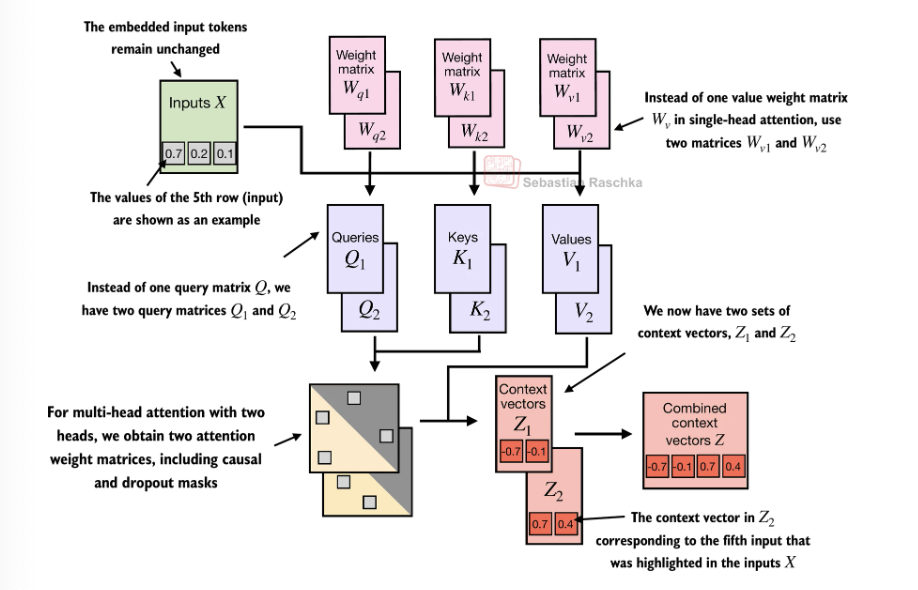

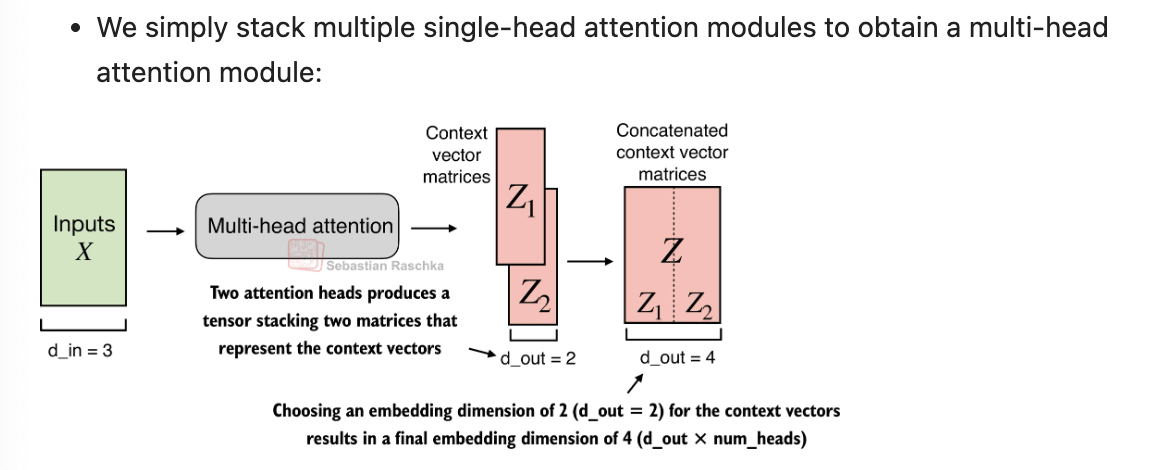

* The main idea of multi-head attention is to run the attention mechanism multiple times (in parallel) with different, learned linear projections. This allows the model to jointly attend to information from different representation subspaces at different positions.

In [96]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)

context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)


tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


##### Multi-head attention with weight splits

In this, we don't concatenate single attention heads. We create single W_query, W_key and W_value weight matrices and then split those into individual matrices for each attention head.

Below is a more efficient version of MultiHeadAttentionWrapper

For the compact and efficient implementation of below class, torch.nn.MultiheadAttention class in PyTorch can be considered.

In [97]:
from httpx import head


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # 2//2 = 1
        print("d_in: ", d_in) # 3
        print("d_out:", d_out) # 2
        print("context_length:", context_length) # 6 (number of tokens)
        print("number of heads:", num_heads) # 2
        print("\n")

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias) # (6,3) @ (3,2) = (6,2)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        print("W_query.shape (W_query = nn.Linear(d_in, d_out, bias=qkv_bias)):", W_query.shape)
        print("W_key.shape:", W_key.shape)
        print("W_value.shape:", W_value.shape)
        print("\n")

        self.out_proj = nn.Linear(d_out, d_out) # Linear layer to combine head outputs. Std convention, not necessary. 
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        print("x.shape: b, num_tokens, d_in:", x.shape)
        b, num_tokens, d_in = x.shape #(4,6,3)

        keys = self.W_key(x) # (b, num_tokens, d_in) @ (d_in, d_out) = (b, num_tokens, d_out) i.e. (4, 6, 2)
        queries = self.W_query(x)
        values = self.W_value(x)

        #slicing the bigger dout into smaller head_dout for each head
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) #(4, 6, 2, 1)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        print("keys(x @ W_key) shape:", keys.shape)
        print("values(x @ W_value) shape:", values.shape)
        print("queries(x @ W_query) shape:", queries.shape)
        print("\n")

        # To make the heads behave like batch dimensions and to make the matrix multiplication work, we need to transpose the head dimension and the head_dout dimension
        # In PyTorch, the @ (matmul) operator treats the last two dimensions as the matrix and everything before them as batch dimensions. By moving num_heads to position 1:
        # PyTorch treats each head as an independent "mini-batch."
        # The attention calculation happens inside each head separately.
        # Without this, the math would accidentally mix information between heads during the dot product, which defeats the purpose of having separate heads!

        keys = keys.transpose(1,2) # (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim) i.e. (4, 2, 6, 1)
        print("keys.transpose(1,2) shape:",keys.shape)
        queries = queries.transpose(1,2)
        print("queries.transpose(1,2 shape):",queries.shape)
        values = values.transpose(1,2)
        print("values.transpose(1,2) shape:",values.shape)
        print("\n")

        # To calculate similarity QKt. Each head will have its own private "Attention Map" showing how every token in that head relates to every other token.
        print("keys.transpose(2,3) shape:", keys.transpose(2,3).shape)
        attn_scores = queries @ keys.transpose(2,3) # (b, num_heads, num_tokens, head_dim) @ (b, num_heads, head_dim, num_tokens) -> (b, num_heads, num_tokens, num_tokens)
        print("attn_scores (queries @ keys.transpose(2,3)) shape:",attn_scores.shape)
        print("The matrix multiplication implementation in PyTorch will handle the 4-dimensional input tensor so that the matrix multiplication is carried out between the 2 last dimensions (num_tokens, head_dim) and then repeated for the individual heads")
        print("\n")

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # We take transpose to swap num_heads and num_tokens back.
        context_vec = (attn_weights @ values).transpose(1,2) # (b, num_heads, num_tokens, num_tokens) @ (b, num_heads, num_tokens, head_dim) -> (b, num_heads, num_tokens, head_dim) -> transpose(1,2) -> (b, num_tokens, num_heads, head_dim)

        # .transpose() does not move any data around in RAM. It just changes the way the data is indexed. So, after transpose, the tensor still has the same shape and the same data in memory, but the way we access that data has changed.
        # We use contiguous() to ensure that the tensor is stored in a contiguous chunk of memory, which is necessary before calling view() to reshape the tensor. This is because operations like transpose can result in non-contiguous tensors, and view() requires the tensor to be contiguous to work correctly.
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) #optional projection

        return context_vec
    

torch.manual_seed(123)
print("inputs: ", inputs)
print("\n")
batch = torch.stack([inputs]*4, dim = 0)
print("batch (torch.stack([inputs]*4, dim = 0)):", batch)
print("\n batch shape (num of stack, len of tokens, ip embedding dim):", batch.shape)
batch_size, context_length, d_in = batch.shape
d_out = 2 #or use d_out = 4 for exact output as MultiHeadAttentionWrapper
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads = 2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

inputs:  tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])


batch (torch.stack([inputs]*4, dim = 0)): tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
 

To compute the matrix multiplication for each head separately in compact way:

In [98]:
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In [99]:
context_vecs

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)